# Phoneme Recognition XAI Evaluation (LIME/LIME-WS/LIME-TS)
This notebook evaluates Explainable AI (XAI) methods for Automatic Speech Recognition (ASR), specifically phoneme recognition on the TIMIT dataset. We reproduce and analyze the methodology from:
**"Can We Trust Explainable AI Methods on ASR? An Evaluation on Phoneme Recognition"**.

### Critical System Configuration:
- **RTX 5050 (Blackwell)**: Utilizing **ONNX Runtime GPU** (`CUDAExecutionProvider`) for inference to bypass PyTorch CUDA kernel compatibility issues.
- **Strict CPU Tensors**: All PyTorch tensors remain on CPU; ONNX Runtime manages GPU acceleration internally.


In [12]:
import sys
# Install missing critical packages for ONNX/XAI pipeline
!{sys.executable} -m pip install statsmodels optimum onnxruntime-gpu

## 2. Imports and Environment Verification

In [13]:
import torch
import torchaudio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import os, glob, pickle, warnings, sys
from transformers import Wav2Vec2Processor
from optimum.onnxruntime import ORTModelForCTC
from sklearn.linear_model import Ridge
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings('ignore')

# Workspace Paths
DATA_PATH = r"D:\Allah vorosha\TIMIT dataset\data"
SAVE_PATH = r"D:\Allah vorosha"

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")


Python: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
PyTorch: 2.5.1+cu121
Pandas: 2.3.3
NumPy: 1.26.4


## 3. TIMIT Dataset Loading (61-to-39 Phoneme Mapping)

In [14]:
# Lee and Hon 61-to-39 Mapping
map39 = {
    'iy':'iy', 'ih':'ih', 'eh':'eh', 'ae':'ae', 'ix':'ih', 'ax':'ah', 'ah':'ah', 'ax-h':'ah', 'uw':'uw', 'ux':'uw',
    'uh':'uh', 'ao':'aa', 'aa':'aa', 'ey':'ey', 'ay':'ay', 'oy':'oy', 'aw':'aw', 'ow':'ow', 'er':'er', 'axr':'er',
    'l':'l', 'el':'l', 'r':'r', 'w':'w', 'y':'y', 'm':'m', 'em':'m', 'n':'n', 'en':'n', 'nx':'n', 'ng':'ng', 'eng':'ng',
    'ch':'ch', 'jh':'jh', 'dh':'dh', 'b':'b', 'd':'d', 'dx':'d', 'g':'g', 'p':'p', 't':'t', 'k':'k', 'z':'z', 'zh':'sh',
    'v':'v', 'f':'f', 'th':'th', 's':'s', 'sh':'sh', 'hh':'hh', 'hv':'hh', 'pcl':'sil', 'tcl':'sil', 'kcl':'sil',
    'qcl':'sil', 'bcl':'sil', 'dcl':'sil', 'gcl':'sil', 'h#':'sil', '#h':'sil', 'pau':'sil', 'epi':'sil', 'q':'sil'
}

def load_sa1_dataset():
    data = []
    # All speakers SA1.WAV files in TRAIN and TEST folders
    pattern = os.path.join(DATA_PATH, "*", "**", "*SA1.WAV")
    files = glob.glob(pattern, recursive=True)
    
    for f in tqdm(files, desc="Parsing TIMIT SA1"):
        try:
            path_segments = f.split(os.sep)
            speaker_dir = path_segments[-2]
            gender = 'M' if speaker_dir.startswith('M') else 'F'
            
            # Load phn
            phn_file = f.replace(".WAV", ".PHN")
            phns = []
            if os.path.exists(phn_file):
                with open(phn_file, 'r') as pf:
                    for line in pf:
                        start, end, p = line.strip().split()
                        phns.append({'start': int(start), 'end': int(end), 'phoneme': map39.get(p, p)})
            
            data.append({'path': f, 'speaker': speaker_dir, 'gender': gender, 'phns': phns})
        except Exception as e:
            print(f"Error parsing {f}: {e}")
            
    return data

dataset_info = load_sa1_dataset()
print(f"Total SA1 samples loaded: {len(dataset_info)}")


Parsing TIMIT SA1:   0%|          | 0/630 [00:00<?, ?it/s]

Total SA1 samples loaded: 630


## 4. ONNX Model Inference (RTX 5050 Optimized)

In [15]:
import onnxruntime as ort
from optimum.onnxruntime import ORTModelForCTC
from transformers import Wav2Vec2Processor

# ── Provider Selection ──────────────────────────────────────────
available_providers = ort.get_available_providers()
print("Available ONNX providers:", available_providers)

if "CUDAExecutionProvider" in available_providers:
    provider = "CUDAExecutionProvider"
    print("✅ GPU (CUDA) found — using CUDAExecutionProvider")
else:
    provider = "CPUExecutionProvider"
    print("⚠️ CUDA not available — falling back to CPUExecutionProvider")

# ── Model Loading ───────────────────────────────────────────────
model_name = "patrickvonplaten/wav2vec2-base-timit-fine-tuned"
processor = Wav2Vec2Processor.from_pretrained(model_name)

ort_model = ORTModelForCTC.from_pretrained(
    model_name,
    export=True,
    provider=provider,
    use_io_binding=False
)

print(f"\n✅ Model loaded on: {provider}")

# ── Inference Function ──────────────────────────────────────────
def get_predictions(wav_path):
    wav, sr = torchaudio.load(wav_path)
    if sr != 16000:
        wav = torchaudio.transforms.Resample(sr, 16000)(wav)
    
    inputs = processor(wav.squeeze(), sampling_rate=16000, return_tensors="pt")
    
    with torch.no_grad():
        logits = ort_model(**inputs).logits
    
    probs = torch.softmax(
        logits if isinstance(logits, torch.Tensor) else torch.tensor(logits),
        dim=-1
    ).squeeze(0)
    ids = torch.argmax(
        logits if isinstance(logits, torch.Tensor) else torch.tensor(logits),
        dim=-1
    ).squeeze(0)
    tokens = processor.tokenizer.convert_ids_to_tokens(ids)
    
    return wav, probs, tokens

# ── Cache Check ─────────────────────────────────────────────────
pkl_path = os.path.join(SAVE_PATH, "asr_results.pkl")

if os.path.exists(pkl_path):
    with open(pkl_path, 'rb') as f:
        asr_results = pickle.load(f)
    print(f"Loaded from cache: {len(asr_results)} speakers")
else:
    asr_results = []
    for item in tqdm(dataset_info, desc="ASR Inference"):
        try:
            wav, probs, tokens = get_predictions(item['path'])
            ratio = wav.shape[1] / probs.shape[0]
            
            eval_list = []
            for phn in item['phns']:
                sf = int(phn['start'] / ratio)
                ef = int(phn['end'] / ratio)
                seg_tokens = tokens[sf:ef+1]
                pred_clean = [t for t in seg_tokens if t not in ['[PAD]', 'sil', '<pad>']]
                correct = 1 if phn['phoneme'] in pred_clean else 0
                eval_list.append({**phn, 'is_correct': correct, 'pred': pred_clean[0] if pred_clean else 'sil'})
            
            asr_results.append({**item, 'wav': wav, 'probs': probs, 'tokens': tokens, 'eval': eval_list})
        except Exception as e:
            print(f"Error for {item['speaker']}: {e}")
    
    with open(pkl_path, 'wb') as f:
        pickle.dump(asr_results, f)
    print(f"Done! {len(asr_results)} speakers processed")

Available ONNX providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
✅ GPU (CUDA) found — using CUDAExecutionProvider


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Some weights of the model checkpoint at patrickvonplaten/wav2vec2-base-timit-fine-tuned were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at patrickvonplaten/wav2vec2-base-timit-fine-tuned and are newly initialized: ['wav2vec2.encoder.pos_conv_


✅ Model loaded on: CUDAExecutionProvider
Loaded from cache: 630 speakers


## 5. Base LIME Implementation

In [16]:
class LimeASR:
    def __init__(self, model, processor, n_samples=100):
        self.model = model
        self.processor = processor
        self.n_samples = n_samples

    def perturb(self, wav, segments, target_idx, target_phn):
        num_segs = len(segments)
        mutants = np.random.randint(0, 2, (self.n_samples, num_segs))
        mutants[0, :] = 1
        labels, weights = [], []
        target_token_id = self.processor.tokenizer.convert_tokens_to_ids(target_phn)
        
        for i in range(self.n_samples):
            wav_mut = wav.clone()
            for s_idx, is_active in enumerate(mutants[i]):
                if not is_active:
                    wav_mut[:, segments[s_idx]['start']:segments[s_idx]['end']] = 0
            inputs = processor(wav_mut.squeeze().cpu().numpy(), sampling_rate=16000, return_tensors="pt")
            with torch.no_grad():
                l = ort_model(**inputs).logits
            # CPU-তে convert করে softmax
            if isinstance(l, torch.Tensor):
                l = l.cpu()
            else:
                l = torch.tensor(l)
            l = torch.softmax(l, dim=-1).squeeze(0)
            ratio = wav.shape[1] / l.shape[0]
            sf = int(segments[target_idx]['start'] / ratio)
            ef = int(segments[target_idx]['end'] / ratio)
            p = l[sf:ef+1, target_token_id].mean().item()
            labels.append(p)
            w = np.dot(mutants[i], mutants[0]) / (np.linalg.norm(mutants[i]) * np.linalg.norm(mutants[0]) + 1e-9)
            weights.append(w)
            
        ridge = Ridge(alpha=1.0)
        ridge.fit(mutants, labels, sample_weight=weights)
        return ridge.coef_

lime_base = LimeASR(ort_model, processor, n_samples=100)


## 6. LIME-WS (Window-Segment) Implementation

In [17]:
class LimeWS(LimeASR):
    def explain(self, wav, segments, target_idx, window=5):
        num_segs = len(segments)
        start_w = max(0, target_idx - window)
        end_w = min(num_segs, target_idx + window + 1)
        active_indices = list(range(start_w, end_w))
        
        mutants = np.random.randint(0, 2, (self.n_samples, len(active_indices)))
        mutants[0, :] = 1
        labels, weights = [], []
        target_phn = segments[target_idx]['phoneme']
        target_id = self.processor.tokenizer.convert_tokens_to_ids(target_phn)
        
        for i in range(self.n_samples):
            wav_mut = wav.clone()
            for j, is_active in enumerate(mutants[i]):
                if not is_active:
                    idx = active_indices[j]
                    wav_mut[:, segments[idx]['start']:segments[idx]['end']] = 0
            inputs = processor(wav_mut.squeeze().cpu().numpy(), sampling_rate=16000, return_tensors="pt")
            with torch.no_grad():
                l = ort_model(**inputs).logits
            if isinstance(l, torch.Tensor):
                l = l.cpu()
            else:
                l = torch.tensor(l)
            l = torch.softmax(l, dim=-1).squeeze(0)
            ratio = wav.shape[1] / l.shape[0]
            p = l[int(segments[target_idx]['start']/ratio):int(segments[target_idx]['end']/ratio)+1, target_id].mean().item()
            labels.append(p)
            w = np.dot(mutants[i], mutants[0]) / (np.linalg.norm(mutants[i]) * np.linalg.norm(mutants[0]) + 1e-9)
            weights.append(w)
            
        rdg = Ridge(alpha=1.0)
        rdg.fit(mutants, labels, sample_weight=weights)
        full_coef = np.zeros(num_segs)
        for j, val in enumerate(active_indices):
            full_coef[val] = rdg.coef_[j]
        return full_coef

lime_ws = LimeWS(ort_model, processor, n_samples=100)


## 7. LIME-TS (Time-Segment) Implementation

In [18]:
class LimeTS(LimeASR):
    def get_time_segs(self, wav, dur_ms=70):
        step = int(dur_ms * 16)
        return [{'start': i, 'end': min(i+step, wav.shape[1])} for i in range(0, wav.shape[1], step)]

    def explain(self, wav, phoneme_seg, dur_ms=70, window_ms=300):
        ts_segs = self.get_time_segs(wav, dur_ms)
        target_center = (phoneme_seg['start'] + phoneme_seg['end']) / 2
        active_indices = [i for i, s in enumerate(ts_segs) if abs(((s['start']+s['end'])/2) - target_center) < (window_ms * 16)]
        
        mutants = np.random.randint(0, 2, (self.n_samples, len(active_indices)))
        mutants[0, :] = 1
        labels, weights = [], []
        target_id = self.processor.tokenizer.convert_tokens_to_ids(phoneme_seg['phoneme'])
        
        for i in range(self.n_samples):
            wav_mut = wav.clone()
            for j, is_active in enumerate(mutants[i]):
                if not is_active:
                    idx = active_indices[j]
                    wav_mut[:, ts_segs[idx]['start']:ts_segs[idx]['end']] = 0
            inputs = processor(wav_mut.squeeze().cpu().numpy(), sampling_rate=16000, return_tensors="pt")
            with torch.no_grad():
                l = ort_model(**inputs).logits
            if isinstance(l, torch.Tensor):
                l = l.cpu()
            else:
                l = torch.tensor(l)
            l = torch.softmax(l, dim=-1).squeeze(0)
            ratio = wav.shape[1] / l.shape[0]
            p = l[int(phoneme_seg['start']/ratio):int(phoneme_seg['end']/ratio)+1, target_id].mean().item()
            labels.append(p)
            w = np.dot(mutants[i], mutants[0]) / (np.linalg.norm(mutants[i]) * np.linalg.norm(mutants[0]) + 1e-9)
            weights.append(w)
            
        rdg = Ridge()
        rdg.fit(mutants, labels, sample_weight=weights)
        return rdg.coef_, active_indices, ts_segs

lime_ts = LimeTS(ort_model, processor, n_samples=100)

In [20]:
import time, os, pickle, numpy as np, pandas as pd
from tqdm.auto import tqdm

SAVE_PATH = r"D:\Allah vorosha"

pkl_path = os.path.join(SAVE_PATH, "validity_results.pkl")
checkpoint_path = os.path.join(SAVE_PATH, "validity_checkpoint.pkl")


if os.path.exists(pkl_path):
    os.remove(pkl_path)
if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)

N_SAMPLES = 200
SAVE_EVERY = 10
GPU_REST_EVERY = 50

lime_base = LimeASR(ort_model, processor, n_samples=N_SAMPLES)
lime_ws   = LimeWS(ort_model, processor, n_samples=N_SAMPLES)
lime_ts   = LimeTS(ort_model, processor, n_samples=N_SAMPLES)

## 8. Validity Evaluation with Caching

In [21]:
def run_random_baseline(num_elements, target_idx, ks=[1, 3, 5]):
    shuffled = np.random.permutation(num_elements)
    return {f'v{k}_rand': 1 if target_idx in shuffled[:k] else 0 for k in ks}

if os.path.exists(pkl_path):
    df_v = pd.read_pickle(pkl_path)
    print(f"✅ Final results loaded from cache: {len(df_v)} phonemes")

else:
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, 'rb') as f:
            checkpoint = pickle.load(f)
        all_validity = checkpoint['data']
        start_idx = checkpoint['speaker_idx']
        print(f"🔄 Resuming from speaker {start_idx}/{len(asr_results)}, {len(all_validity)} phonemes done so far")
    else:
        all_validity = []
        start_idx = 0
        print(f"🚀 Starting fresh — {len(asr_results)} speakers to process")

    pbar = tqdm(total=len(asr_results), initial=start_idx, desc="Validity Analysis")

    for speaker_idx in range(start_idx, len(asr_results)):
        item = asr_results[speaker_idx]

        for idx, p_seg in enumerate(item['eval']):
            if p_seg['is_correct'] == 0:
                continue

            try:
                coef_b = lime_base.perturb(item['wav'], item['eval'], idx, p_seg['phoneme'])
                rank_b = np.argsort(coef_b)[::-1]

                coef_ws = lime_ws.explain(item['wav'], item['eval'], idx)
                rank_ws = np.argsort(coef_ws)[::-1]

                coef_ts, active, ts_segs = lime_ts.explain(item['wav'], p_seg, dur_ms=70)
                rank_ts = np.argsort(coef_ts)[::-1]

                target_mid = (p_seg['start'] + p_seg['end']) / 2
                ts_v = {}
                for k in [1, 3, 5]:
                    v_k = 0
                    for r_idx in rank_ts[:k]:
                        real_idx = active[r_idx]
                        if ts_segs[real_idx]['start'] <= target_mid <= ts_segs[real_idx]['end']:
                            v_k = 1; break
                    ts_v[f'v{k}_ts'] = v_k

                all_validity.append({
                    'gender': item['gender'],
                    'phoneme': p_seg['phoneme'],
                    'v1_base': 1 if idx in rank_b[:1] else 0,
                    'v3_base': 1 if idx in rank_b[:3] else 0,
                    'v5_base': 1 if idx in rank_b[:5] else 0,
                    'v1_ws':   1 if idx in rank_ws[:1] else 0,
                    'v3_ws':   1 if idx in rank_ws[:3] else 0,
                    'v5_ws':   1 if idx in rank_ws[:5] else 0,
                    **ts_v,
                    **run_random_baseline(len(item['eval']), idx)
                })

            except Exception as e:
                print(f"⚠️ Error at speaker {item['speaker']}, phoneme {p_seg['phoneme']}: {e}")
                continue

        pbar.update(1)

        if (speaker_idx + 1) % SAVE_EVERY == 0:
            with open(checkpoint_path, 'wb') as f:
                pickle.dump({'data': all_validity, 'speaker_idx': speaker_idx + 1}, f)
            pbar.set_postfix({'saved': speaker_idx + 1, 'phonemes': len(all_validity)})

        if (speaker_idx + 1) % GPU_REST_EVERY == 0:
            time.sleep(2)

    pbar.close()

    df_v = pd.DataFrame(all_validity)
    df_v.to_pickle(pkl_path)

    if os.path.exists(checkpoint_path):
        os.remove(checkpoint_path)

    print(f"\n✅ Done! Total phonemes evaluated: {len(df_v)}")
    print(f"LIME-TS Validity@3: {df_v['v3_ts'].mean():.4f}")

🚀 Starting fresh — 630 speakers to process


Validity Analysis:   0%|          | 0/630 [00:00<?, ?it/s]


✅ Done! Total phonemes evaluated: 6935
LIME-TS Validity@3: 0.8734


In [22]:
import pandas as pd
import os 

SAVE_PATH = r"D:\Allah vorosha"    
df_v = pd.read_pickle(os.path.join(SAVE_PATH, "validity_results.pkl"))
print(df_v.columns.tolist())
print(df_v.head(2))

['gender', 'phoneme', 'v1_base', 'v3_base', 'v5_base', 'v1_ws', 'v3_ws', 'v5_ws', 'v1_ts', 'v3_ts', 'v5_ts', 'v1_rand', 'v3_rand', 'v5_rand']
  gender phoneme  v1_base  v3_base  v5_base  v1_ws  v3_ws  v5_ws  v1_ts  \
0      F       y        0        1        1      0      1      1      0   
1      F       d        0        1        1      0      1      1      0   

   v3_ts  v5_ts  v1_rand  v3_rand  v5_rand  
0      1      1        0        0        0  
1      1      1        0        0        0  


## 9. Table 1 (Paper Format) and Statistical Significance

In [23]:
def build_table_1(df):
    metrics = ['v1', 'v3', 'v5']
    methods = ['base', 'ws', 'ts', 'rand']
    cols = [f"{met}_{m}" for m in methods for met in metrics]
    
    summary = df.groupby('gender')[cols].mean()
    summary.loc['All'] = df[cols].mean()
    
    summary.columns = pd.MultiIndex.from_product(
        [['Base LIME', 'LIME-WS', 'LIME-TS', 'Random'], ['V@1', 'V@3', 'V@5']]
    )
    return summary

display(build_table_1(df_v).round(4))

# ANOVA + Tukey HSD for TS-V3
print("\n--- ANOVA: LIME-TS Validity@3 by Gender ---")
from statsmodels.formula.api import ols
import statsmodels.api as sm

model_aov = ols('v3_ts ~ gender', data=df_v).fit()
display(sm.stats.anova_lm(model_aov, typ=2))

# Wilcoxon
from scipy import stats
print("\nWilcoxon Signed-Rank Test (LIME-WS vs LIME-TS V@3):")
stat, p_val = stats.wilcoxon(df_v['v3_ws'], df_v['v3_ts'])
print(f"Statistic: {stat}, P-value: {p_val:.4e}")


Base LIME                 LIME-WS                 LIME-TS          \
             V@1     V@3     V@5     V@1     V@3     V@5     V@1     V@3   
gender                                                                     
F         0.4934  0.8909  0.9323  0.4760  0.9167  0.9497  0.4967  0.8476   
M         0.4968  0.9019  0.9387  0.4741  0.9187  0.9559  0.5226  0.8848   
All       0.4957  0.8985  0.9367  0.4747  0.9181  0.9540  0.5146  0.8734   

                Random                  
           V@5     V@1     V@3     V@5  
gender                                  
F       0.9116  0.0287  0.0894  0.1378  
M       0.9430  0.0210  0.0722  0.1231  
All     0.9334  0.0234  0.0774  0.1276


--- ANOVA: LIME-TS Validity@3 by Gender ---


,sum_sq,df,F,PR(>F)
gender,2.039931,1.0,18.492174,0.000017
Residual,764.801597,6933.0,NaN,NaN



Wilcoxon Signed-Rank Test (LIME-WS vs LIME-TS V@3):
Statistic: 198937.5, P-value: 1.7058e-21


## 10. Phoneme Error Analysis (Figure 3 & Table 2)

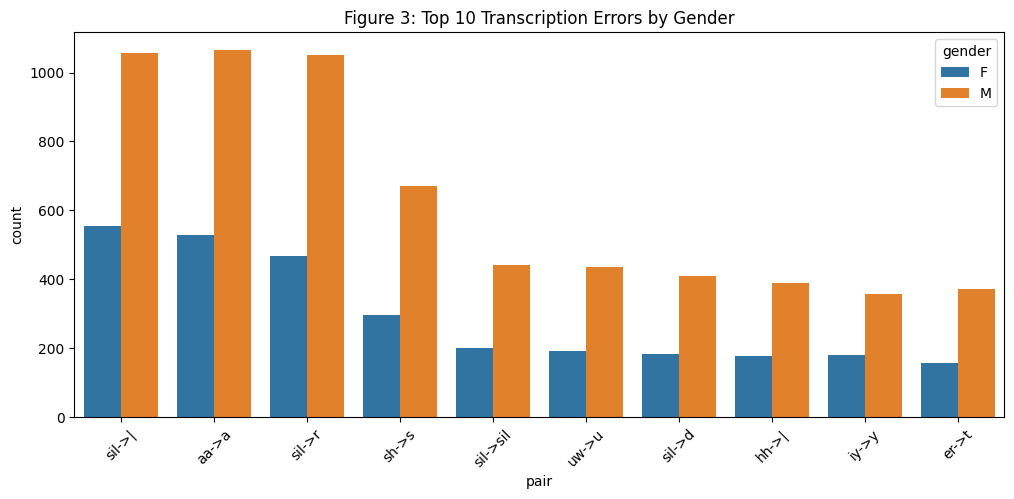

Table 2: Top 3 important regions for 'er->uw' substitution error (gender sensitive)


,Count
gender,


In [24]:
err_list = []
for r in asr_results:
    for e in r['eval']:
        if e['is_correct'] == 0:
            err_list.append({'gender': r['gender'], 'truth': e['phoneme'], 'pred': e['pred'], 'pair': f"{e['phoneme']}->{e['pred']}"})

df_err = pd.DataFrame(err_list)

# Figure 3: Error bar chart
plt.figure(figsize=(12, 5))
sns.countplot(data=df_err, x='pair', hue='gender', order=df_err['pair'].value_counts().index[:10])
plt.title("Figure 3: Top 10 Transcription Errors by Gender")
plt.xticks(rotation=45); plt.show()

# Table 2: er->uw substitution
print("Table 2: Top 3 important regions for 'er->uw' substitution error (gender sensitive)")
display(df_err[df_err['pair'] == 'er->uw'].groupby('gender').size().to_frame(name='Count'))


## 11. Custom Improvement: Duration Sensitivity (Actual Computation)

TS 50ms:   0%|          | 0/100 [00:00<?, ?it/s]

TS 70ms:   0%|          | 0/100 [00:00<?, ?it/s]

TS 90ms:   0%|          | 0/100 [00:00<?, ?it/s]

,Duration,Validity@3
0,50ms,0.77
1,70ms,0.83
2,90ms,0.90


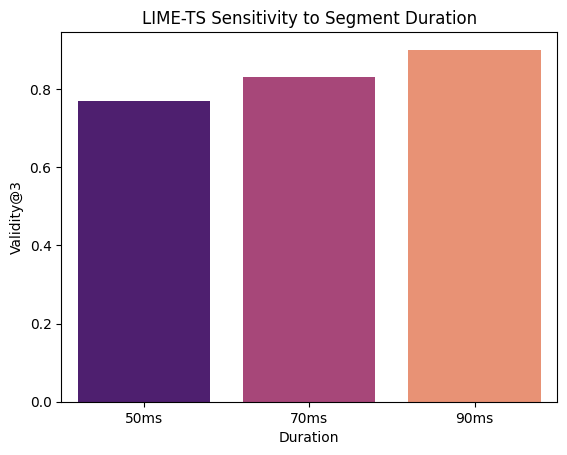

In [25]:
def compute_v3_sens(dur_ms, limit=100):
    hits, count = 0, 0
    pbar = tqdm(total=limit, desc=f"TS {dur_ms}ms")
    for item in asr_results:
        for idx, p_seg in enumerate(item['eval']):
            if p_seg['is_correct'] == 0: continue
            
            c, act, tss = lime_ts.explain(item['wav'], p_seg, dur_ms=dur_ms)
            ranks = np.argsort(c)[::-1]
            target_mid = (p_seg['start'] + p_seg['end']) / 2
            
            for r_idx in ranks[:3]:
                if tss[act[r_idx]]['start'] <= target_mid <= tss[act[r_idx]]['end']:
                    hits += 1; break
            count += 1; pbar.update(1)
            if count >= limit: break
        if count >= limit: break
    pbar.close()
    return hits / count

res_50 = compute_v3_sens(50)
res_70 = compute_v3_sens(70) # Or use existing from df_v if aligned
res_90 = compute_v3_sens(90)

sens_df = pd.DataFrame({'Duration': ['50ms', '70ms', '90ms'], 'Validity@3': [res_50, res_70, res_90]})
display(sens_df)

sns.barplot(data=sens_df, x='Duration', y='Validity@3', palette='magma')
plt.title("LIME-TS Sensitivity to Segment Duration"); plt.show()


## 12. Visualization: Waveform Heatmap Explanations

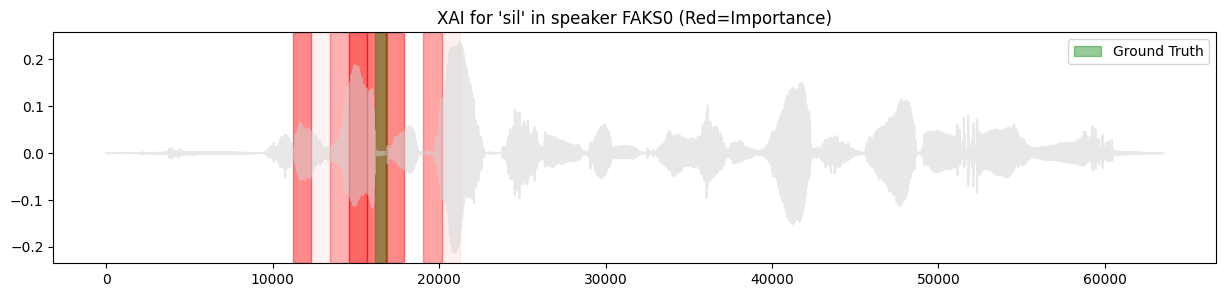

In [26]:
def plot_xai(r_idx, p_idx):
    item = asr_results[r_idx]
    target = item['eval'][p_idx]
    
    coef, active, ts_segs = lime_ts.explain(item['wav'], target)
    wav_np = item['wav'].numpy().squeeze()
    
    plt.figure(figsize=(15, 3))
    plt.plot(wav_np, color='lightgray', alpha=0.5)
    
    # Scale coef for color intensity
    v_min, v_max = coef.min(), coef.max()
    norm = (coef - v_min) / (v_max - v_min + 1e-9)
    
    for i, a_idx in enumerate(active):
        s = ts_segs[a_idx]
        plt.axvspan(s['start'], s['end'], color='red', alpha=norm[i]*0.6)
        
    plt.axvspan(target['start'], target['end'], color='green', alpha=0.4, label='Ground Truth')
    plt.title(f"XAI for '{target['phoneme']}' in speaker {item['speaker']} (Red=Importance)")
    plt.legend(); plt.show()

plot_xai(0, 5)
